In [2]:
import openai
import re
import time
import json

import numpy as np

from tqdm import tqdm
from pprint import pprint
from tenacity import retry, stop_after_attempt, wait_chain, wait_fixed

import os
from openai import AzureOpenAI

import math

import re
import math
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor
import traceback

from datetime import datetime

import concurrent.futures
import os
import json
from datetime import datetime

In [3]:
def load_json(path):
    with open(path, 'r', encoding='utf-8') as reader:
        data = json.load(reader)  # Load the entire JSON file
    return data

# Load the datasets
ASDIV = load_json('../../testingDatasets/ASDIVsampled_train.json')
ADDSUB = load_json('../../testingDatasets/AddSubsampled_train.json')
AQUA = load_json('../../testingDatasets/AQuAsampled_train.json')
GSM = load_json('../../testingDatasets/GSMsampled_train.json')
MUlTIARTH = load_json('../../testingDatasets/MultiArthsampled_train.json')
SVAMP = load_json('../../testingDatasets/SVAMPsampled_train.json')

# Load Examplars
hypothesis_CoT_prompt_examples = open('../../research/GPT4_Turbo/prompt_examples/hypothesis_CoT_prompt_examples.txt').read()
hypothesis_Standard_prompt_examples = open('../../research/GPT4_Turbo/prompt_examples/hypothesis_Standard_prompt_examples.txt').read()
hypothesis_CCoT_prompt_examples = open('../../research/GPT4_Turbo/prompt_examples/hypothesis_CCoT_prompt_examples.txt').read()
CoT_prompt_examples = open('../../research/GPT4_Turbo/prompt_examples/CoT_prompt_examples.txt').read()
Standard_prompt_examples = open("../../research/GPT4_Turbo/prompt_examples/standard_prompt_examples.txt").read()
CCoT_prompt_examples = open("../../research/GPT4_Turbo/prompt_examples/CCoT_prompt_example.txt").read()

In [4]:
endpoint = os.environ["AZURE_OPENAI_ENDPOINT"]
model_name = "gpt-4o"
deployment = "gpt-4o"
subscription_key = os.environ["AZURE_OPENAI_API_KEY"]
api_version = "2024-12-01-preview"

client = AzureOpenAI(
    api_version=api_version,
    azure_endpoint=endpoint,
    api_key=subscription_key,
)

@retry(wait=wait_chain(*[wait_fixed(3) for _ in range(3)] +
                       [wait_fixed(5) for _ in range(2)] +
                       [wait_fixed(10)]))
def completion_with_backoff_4o(messages):
    return client.chat.completions.create(
        messages=messages,
        max_tokens=1512,
        temperature=0.0,
        model=deployment
    )

In [5]:
def clean_and_truncate(value_str):
    cleaned = re.sub(r'[^\d\.\-]', '', value_str)
    try:
        num = float(cleaned)
        return num
    except ValueError:
        return None

def clean_and_truncate(value_str):
    cleaned = re.sub(r'[^\d\.\-]', '', value_str)  # Remove everything except digits, dot, minus
    try:
        return float(cleaned)
    except ValueError:
        return None

def answer_extractor(ans_model):
    # Pattern 1: Markdown-style "### Final Answer:" followed by a number in a sentence
    match = re.search(
        r'###\s*Final Answer:\s*.*?\**\$?(-?(?:\d{1,3}(?:,\d{3})+|\d+)(?:\.\d+)?)\**',
        ans_model,
        re.IGNORECASE | re.DOTALL
    )
    if match:
        value_str = match.group(1).replace(",", "")  # Remove commas
        return clean_and_truncate(value_str)
    # Pattern 2: Standard numerical answer formats
    match = re.search(
        r'(?:the answer is|final answer:)\s*\**\$?(-?(?:\d{1,3}(?:,\d{3})+|\d+)(?:\.\d+)?(?:e[+-]?\d+)?)\**',
        ans_model,
        re.IGNORECASE
    )
    if match:
        value_str = match.group(1).replace(",", "")  # Remove commas
        return clean_and_truncate(value_str)

    # Pattern 3: Multiple-choice answer (A-E)
    match = re.search(r'the answer is\s*\**([A-E])\**', ans_model, re.IGNORECASE)
    if not match:
        match = re.search(r'\b([A-E])\b', ans_model.strip()[-5:], re.IGNORECASE)

    if match:
        predicted_choice = match.group(1).upper()
        if predicted_choice in ['A', 'B', 'C', 'D', 'E']:
            return predicted_choice

    return None

def ground_truth_extractor(d, database_name):
    if database_name == "ASDIV":
        return float(re.search(r'(\d+\.?\d*)', d['answer']).group(1))
    elif database_name == "ADDSUB":
        return float(d['correct'][0])
    elif database_name == "AQUA":
        return d['correct'].strip().upper()
    elif database_name == "GSM":
        return float(d['number_answer'])
    elif database_name == "MUlTIARTH":
        return float(d['correct'][0])
    elif database_name == "SVAMP":
        return float(d['correct'])
    else:
        raise ValueError(f"Unknown dataset: {database_name}")
def question_extractor(d, database_name):
    if database_name == "ASDIV":
        return d['body'] +' '+ d['question']
    elif database_name == "ADDSUB":
        return d['question']
    elif database_name == "AQUA":
        return f"{d['question']}\nOptions:\n{"\n".join(d['options'])}"
    elif database_name == "GSM":
        return d['question']
    elif database_name == "MUlTIARTH":
        return d['question']
    elif database_name == "SVAMP":
        return d['question']
    else:
        raise ValueError(f"Unknown dataset: {database_name}")




def generate_message(question, ablation_type, examples=None, isAQUA=False):
    if examples is None:
        examples = ""

    # Dynamic answer format
    if isAQUA:
        answer_suffix = "The answer is <only option letter>"
    else:
        answer_suffix = "The answer is <only value>"

    # === Prompt instruction by ablation type ===
    if ablation_type == "HFP-Full":
        prompt_instruction = (
            "First, write a high-level hypothesis or plan. "
            "Then, think step by step through the problem using that plan."
        )

    elif ablation_type == "HFP-Suppressed":
        prompt_instruction = (
            "Think step by step through this question. Do not write a hypothesis."
        )

    elif ablation_type == "HFP-Delayed":
        prompt_instruction = (
            "First, solve the problem step by step. "
            "After completing your reasoning, write a high-level hypothesis or plan that summarizes your approach."
        )

    elif ablation_type == "HFP-NoReuse":
        prompt_instruction = (
            "First, write a high-level hypothesis or plan. "
            "Then solve the problem step by step, but do not refer to the plan again while solving."
        )

    else:
        raise ValueError(f"Unknown ablation_type: {ablation_type}")

    # === Build full user prompt ===
    prompt_q = (
        examples +
        "\n\nQ: " + question +
        f"\nA: {prompt_instruction} Write your final answer as: {answer_suffix}"
    )

    messages = [
        {
            "role": "system",
            "content": f"You are solving math problems using Chain-of-Thought reasoning. "
                       f"Follow the ablation mode: {ablation_type}. "
                       f"Write your final answer as: {answer_suffix}"
        },
        {
            "role": "user",
            "content": prompt_q
        }
    ]

    return messages



In [10]:
import os
import json
import math
import re
from datetime import datetime
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm

# === Prompt Mapping by Ablation Type ===
ablation_prompt_map = {
    "HFP-Full": open('../../research/ablation/prompt_examples/HFP-Full.txt').read(),
    "HFP-Suppressed": open('../../research/ablation/prompt_examples/HFP-Suppressed.txt').read(),
    "HFP-Delayed": open('../../research/ablation/prompt_examples/HFP-Delayed.txt').read(),
    "HFP-NoReuse": open('../../research/ablation/prompt_examples/HFP-NoReuse.txt').read()
}

# === Dataset Mapping ===
dataset_map = {
    "AQUA": AQUA,
    "ASDIV": ASDIV,
    "ADDSUB": ADDSUB,
    "GSM": GSM,
    "MUlTIARTH": MUlTIARTH,
    "SVAMP": SVAMP
}

ablation_items = ["HFP-NoReuse", "HFP-Full", "HFP-Suppressed", "HFP-Delayed"]

# === Results Containers ===
all_results = {}
summary_results = {}

# === Function to Process a Single Example ===
def process_item(item, dataset_name, ablation_type, few_shot_examples):
    try:
        question = question_extractor(item, dataset_name)
        ground_truth = ground_truth_extractor(item, dataset_name)
    except Exception as e:
        question = f"[ERROR]: {str(e)}"
        print(f"Error extracting question for {dataset_name}: {e} : {item}")
        ground_truth = 1
        question = "Error extracting question"
    isAQUA = dataset_name == "AQUA"

    messages = generate_message(
        question=question,
        ablation_type=ablation_type,
        examples=few_shot_examples,
        isAQUA=isAQUA
    )

    try:
        model_response = completion_with_backoff_4o(messages)
        model_output = model_response.choices[0].message.content.strip()
    except Exception as e:
        model_output = f"[ERROR]: {str(e)}"

    parsed_answer = answer_extractor(model_output)

    is_correct = False
    try:
        if isinstance(parsed_answer, str) and isinstance(ground_truth, str):
            is_correct = parsed_answer.strip().upper() == ground_truth.strip().upper()
        elif isinstance(parsed_answer, (int, float)) and isinstance(ground_truth, (int, float, str)):
            is_correct = abs(float(parsed_answer) - float(ground_truth)) < 1e-3
    except:
        is_correct = False

    return {
        "question": question,
        "ground_truth": ground_truth,
        "response": model_output,
        "parsed_answer": parsed_answer,
        "is_correct": is_correct
    }

# === Loop Through Ablations and Datasets ===
for ablation_type in ablation_items:
    print(f"\n[INFO] Running ablation type: {ablation_type}")
    all_results[ablation_type] = {}
    summary_results[ablation_type] = {}

    few_shot_examples = ablation_prompt_map[ablation_type]

    for dataset_name, dataset in dataset_map.items():
        print(f"    [INFO] → Dataset: {dataset_name}")
        dataset_results = []
        correct = 0
        total = 0

        with ThreadPoolExecutor() as executor:
            futures = [executor.submit(process_item, item, dataset_name, ablation_type, few_shot_examples) for item in dataset]
            for future in tqdm(as_completed(futures), total=len(dataset), desc=f"{dataset_name}-{ablation_type}"):
                result = future.result()
                dataset_results.append(result)
                total += 1
                if result["is_correct"]:
                    correct += 1
                print(f"    [INFO] → Total Questions: {total}, Correct Answers: {correct}, Current Accuracy: {(correct / total)}")

        accuracy = round((correct / total) * 100, 2) if total > 0 else 0.0
        print(f"        Accuracy: {accuracy:.2f}% ({correct}/{total})")

        summary_results[ablation_type][dataset_name] = {
            "accuracy": accuracy,
            "correct": correct,
            "total": total
        }

        all_results[ablation_type][dataset_name] = dataset_results
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        output_path = f"../../research/ablation/logs/{ablation_type}_{dataset_name}_{timestamp}.json"
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        with open(output_path, 'w', encoding='utf-8') as f:
            json.dump(dataset_results, f, indent=4)

# === Summary Report ===
print("\n=== Summary Accuracy Report ===")
for ablation, dataset_scores in summary_results.items():
    print(f"\n{ablation}")
    for dataset_name, scores in dataset_scores.items():
        print(f"  {dataset_name:10s}: {scores['accuracy']}% ({scores['correct']}/{scores['total']})")



[INFO] Running ablation type: HFP-NoReuse
    [INFO] → Dataset: AQUA


AQUA-HFP-NoReuse:   0%|          | 1/205 [00:03<12:21,  3.64s/it]

    [INFO] → Total Questions: 1, Correct Answers: 1, Current Accuracy: 1.0


AQUA-HFP-NoReuse:   1%|          | 2/205 [00:06<10:46,  3.19s/it]

    [INFO] → Total Questions: 2, Correct Answers: 2, Current Accuracy: 1.0


...

    [INFO] → Total Questions: 201, Correct Answers: 186, Current Accuracy: 0.9253731343283582
    [INFO] → Total Questions: 202, Correct Answers: 187, Current Accuracy: 0.9257425742574258


SVAMP-HFP-Delayed:  99%|█████████▉| 203/205 [09:04<00:04,  2.16s/it]

    [INFO] → Total Questions: 203, Correct Answers: 188, Current Accuracy: 0.9261083743842364
    [INFO] → Total Questions: 204, Correct Answers: 189, Current Accuracy: 0.9264705882352942


SVAMP-HFP-Delayed: 100%|██████████| 205/205 [09:05<00:00,  2.66s/it]

    [INFO] → Total Questions: 205, Correct Answers: 190, Current Accuracy: 0.926829268292683
        Accuracy: 92.68% (190/205)

=== Summary Accuracy Report ===

HFP-NoReuse
  AQUA      : 84.88% (174/205)
  ASDIV     : 96.1% (197/205)
  ADDSUB    : 98.5% (197/200)
  GSM       : 92.0% (184/200)
  MUlTIARTH : 99.51% (204/205)
  SVAMP     : 92.2% (189/205)

HFP-Full
  AQUA      : 85.37% (175/205)
  ASDIV     : 95.12% (195/205)
  ADDSUB    : 98.0% (196/200)
  GSM       : 93.0% (186/200)
  MUlTIARTH : 99.51% (204/205)
  SVAMP     : 92.68% (190/205)

HFP-Suppressed
  AQUA      : 83.9% (172/205)
  ASDIV     : 93.17% (191/205)
  ADDSUB    : 97.0% (194/200)
  GSM       : 93.5% (187/200)
  MUlTIARTH : 99.51% (204/205)
  SVAMP     : 91.71% (188/205)

HFP-Delayed
  AQUA      : 85.85% (176/205)
  ASDIV     : 95.12% (195/205)
  ADDSUB    : 97.0% (194/200)
  GSM       : 92.5% (185/200)
  MUlTIARTH : 99.51% (204/205)
  SVAMP     : 92.68% (190/205)


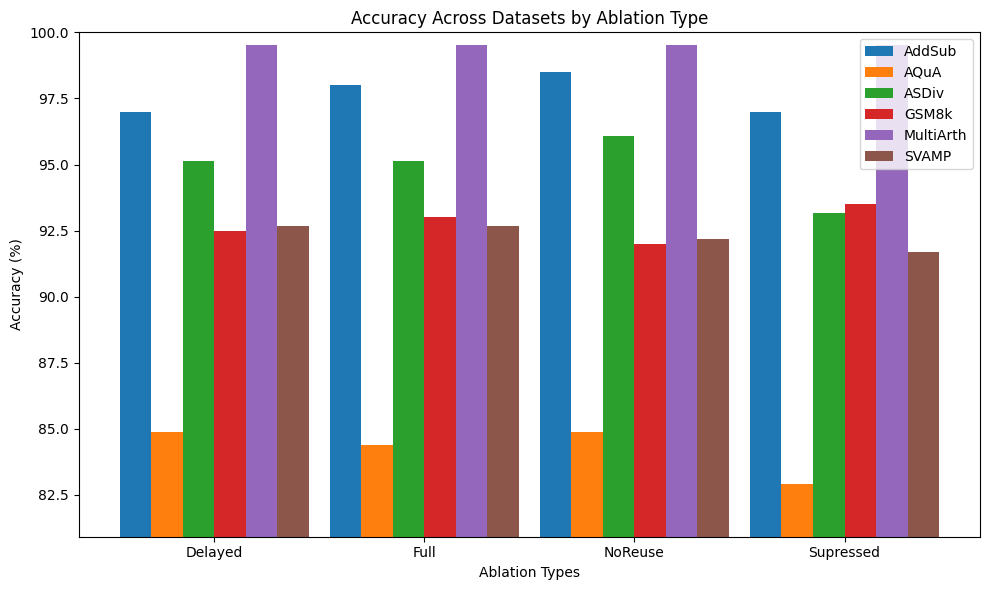

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Data
datasets = {
    "AddSub": [97, 98, 98.50, 97],
    "AQuA": [84.87, 84.39, 84.87, 82.92],
    "ASDiv": [95.12, 95.12, 96.09, 93.17],
    "GSM8k": [92.50, 93.00, 92, 93.50],
    "MultiArth": [99.51, 99.51, 99.51, 99.51],
    "SVAMP": [92.68, 92.68, 92.19, 91.70]
}

# Bar graph settings
x_labels = ["Delayed", "Full", "NoReuse", "Supressed"]
x = np.arange(len(x_labels))  # Positions for bars
width = 0.15  # Width of each bar

# Transpose data to group by indices
grouped_data = list(zip(*datasets.values()))

# Calculate minimum value across all datasets
min_value = min(min(values) for values in datasets.values())
y_min = min_value - 2  # Start scale 2 below the minimum value

# Plot each dataset grouped by index
fig, ax = plt.subplots(figsize=(10, 6))
for i, dataset_name in enumerate(datasets.keys()):
    ax.bar(x + i * width, [group[i] for group in grouped_data], width, label=dataset_name)

# Customize graph
ax.set_xlabel("Ablation Types")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy Across Datasets by Ablation Type")
ax.set_xticks(x + width * (len(datasets) - 1) / 2)
ax.set_xticklabels(x_labels)
ax.set_ylim(y_min, 100)  # Set y-axis limits
ax.legend()

# Show graph
plt.tight_layout()
plt.show()